<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/WHSAT_eda_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Imports necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

data_set = pd.read_csv("https://raw.githubusercontent.com/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/main/IHMStefanini_industrial_safety_and_health_database_with_accidents_description.csv")

In [2]:
# Basic infomation inspection
print(data_set.shape)
print(data_set.columns)
data_set.info()
data_set.head()

(425, 12)
Index(['Unnamed: 0', 'Data', 'Countries', 'Local', 'Industry Sector',
       'Accident Level', 'Potential Accident Level', 'Genre',
       'Employee or Third Party', 'Critical Risk', 'Description',
       'Unnamed: 11'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                425 non-null    int64  
 1   Data                      425 non-null    object 
 2   Countries                 425 non-null    object 
 3   Local                     425 non-null    object 
 4   Industry Sector           425 non-null    object 
 5   Accident Level            425 non-null    object 
 6   Potential Accident Level  425 non-null    object 
 7   Genre                     425 non-null    object 
 8   Employee or Third Party   425 non-null    object 
 9   Critical Risk             425 no

,Unnamed: 0,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description,Unnamed: 11
0,0,1/1/2016 0:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,NaN
1,1,1/2/2016 0:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,NaN
2,2,1/6/2016 0:00,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,NaN
3,3,1/8/2016 0:00,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,NaN
4,4,1/10/2016 0:00,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,NaN


In [3]:
#renaming so that the columns would have a more meaningful identifier
data_set.rename(columns={"Genre": "Gender", "Data": "Date"}, inplace=True)
data_set['Date']= pd.to_datetime(data_set['Date'])
data_set.drop(labels="Unnamed: 0",axis=1,inplace=True)


In [4]:
data_set.head()

,Date,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Gender,Employee or Third Party,Critical Risk,Description,Unnamed: 11
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,NaN
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,NaN
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,NaN
3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,NaN
4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,NaN


In [5]:
#making all the column name lower case and introducing a new seperation "_"
data_set.columns = data_set.columns.str.strip().str.lower().str.replace(" ", "_")
data_set.columns

Index(['date', 'countries', 'local', 'industry_sector', 'accident_level',
       'potential_accident_level', 'gender', 'employee_or_third_party',
       'critical_risk', 'description', 'unnamed:_11'],
      dtype='object')

In [6]:
# Convert date column
data_set['date'] = pd.to_datetime(data_set['date'], errors='coerce')

#extracts hour, weekday (0=Monday), and month from the date column.

data_set['hour'] = data_set['date'].dt.hour
data_set['weekday'] = data_set['date'].dt.weekday
data_set['month'] = data_set['date'].dt.month

#data_set[['date', 'hour', 'weekday', 'month']]
data_set[['date', 'hour', 'weekday', 'month']].tail()

data_set.drop(columns=['hour'], inplace=True)
display(data_set.head())

,date,countries,local,industry_sector,accident_level,potential_accident_level,gender,employee_or_third_party,critical_risk,description,unnamed:_11,weekday,month
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,NaN,4,1
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,NaN,5,1
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,NaN,2,1
3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,NaN,4,1
4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,NaN,6,1


In [7]:
#Accident Level --> I, II, III, IV, V Converting to ordinal 1,2,3,4,5
severity_map = {'I': 1, 'II': 2, 'III': 3,'IV': 4, 'V': 5, 'VI': 6}
data_set['severity'] = data_set['accident_level'].map(severity_map)
data_set['potential_severity'] = data_set['potential_accident_level'].map(severity_map)

In [8]:
#Near-Miss Gap calculation
data_set['near_miss_gap'] = data_set['potential_severity'] - data_set['severity']

In [9]:
#Check missing values
print(data_set.isnull().sum())

#Fill with ""(empty string)
data_set['description'] = data_set['description'].fillna("")

#removing rows with missing severity values
data_set = data_set.dropna(subset=['severity'])

date                          0
countries                     0
local                         0
industry_sector               0
accident_level                0
potential_accident_level      0
gender                        0
employee_or_third_party       0
critical_risk                 0
description                   0
unnamed:_11                 425
weekday                       0
month                         0
severity                      0
potential_severity            0
near_miss_gap                 0
dtype: int64


In [10]:
#categorical_cols = ['industry_sector', 'gender', 'employee_or_third_party', 'critical_risk']
#data_set_encoded = pd.get_dummies(data_set, columns=categorical_cols, drop_first=True)
#data_set_encoded.head()

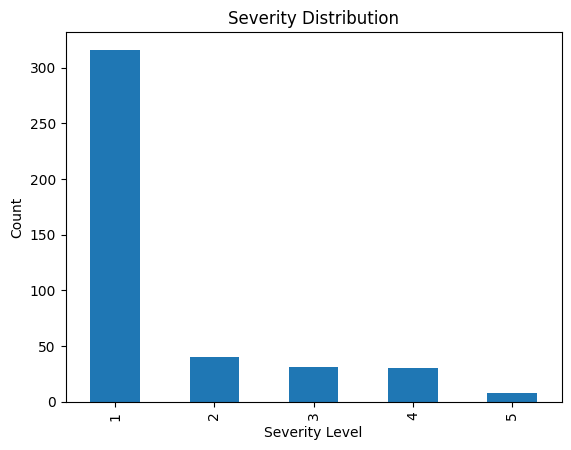

In [11]:
#Visualizes how many accidents occurred at each severity level

data_set['severity'].value_counts().sort_index().plot(kind='bar')
plt.title("Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.show()

Calculating Class Weights

In [12]:
from sklearn.utils.class_weight import compute_class_weight #helps handle imbalanced datasets

# in this data set severity 1 has many cases and severity 5 has very few cases. therefore, the distribution is unbalanced.
classes = np.unique(data_set['severity']) #array[1,2,3,4,5]

weights = compute_class_weight(class_weight='balanced', classes=classes, y=data_set['severity'])
# Formula: weight = n_samples / (n_classes * n_samples_of_this_class)
# eg: total samples = 425, classes = 5
# Class 1 appears 300 times → weight = 425/(5*300) = 0.283
# Class 5 appears 10 times → weight = 425/(5*10) = 8.5

class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(1): np.float64(0.2689873417721519), np.int64(2): np.float64(2.125), np.int64(3): np.float64(2.7419354838709675), np.int64(4): np.float64(2.8333333333333335), np.int64(5): np.float64(10.625)}


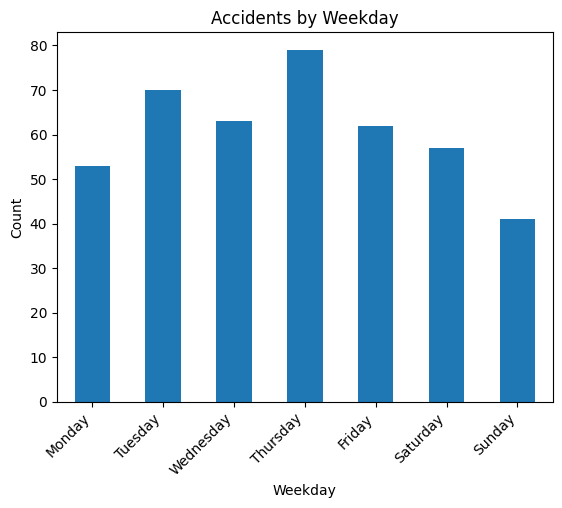

In [13]:
# Accidents by weekday
data_set.groupby('weekday').size().plot(kind='bar')
plt.title("Accidents by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Count")

# Map numerical weekdays to day names
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.xticks(ticks=range(7), labels=weekday_names, rotation=45, ha='right')

plt.show()

 **Critical Risk Analysis**

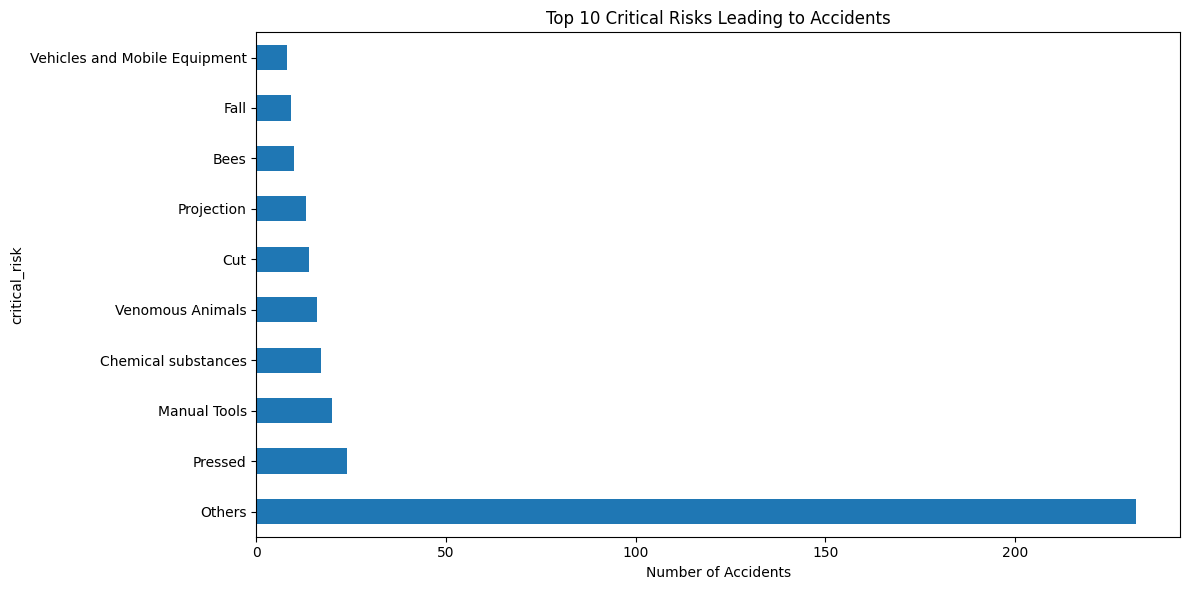

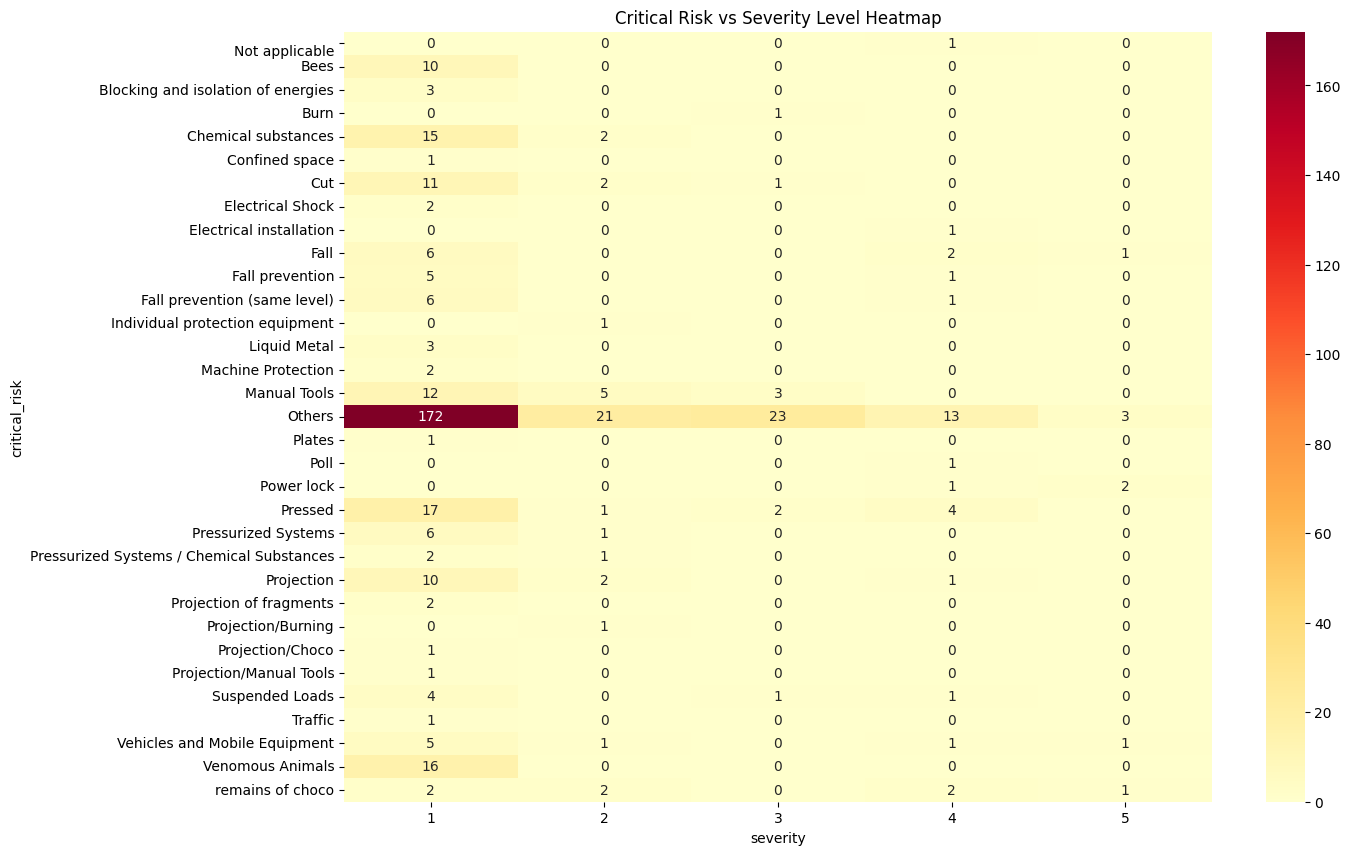

Critical risks causing severe accidents (Severity 4+):
critical_risk
Others                           16
Pressed                           4
Fall                              3
remains of choco                  3
Power lock                        3
Vehicles and Mobile Equipment     2
Fall prevention (same level)      1
Electrical installation           1
Poll                              1
Fall prevention                   1
Suspended Loads                   1
\nNot applicable                  1
Projection                        1
Name: count, dtype: int64


In [14]:
# Top 10 most frequent critical risks
plt.figure(figsize=(12, 6))
data_set['critical_risk'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Critical Risks Leading to Accidents')
plt.xlabel('Number of Accidents')
plt.tight_layout()
plt.show()

# Critical risk vs severity heatmap
critical_severity = pd.crosstab(data_set['critical_risk'], data_set['severity'])
plt.figure(figsize=(14, 10))
sns.heatmap(critical_severity, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Critical Risk vs Severity Level Heatmap')
plt.xticks(rotation=0)
plt.show()

# Most dangerous critical risks (high severity)
high_severity_risks = data_set[data_set['severity'] >= 4]['critical_risk'].value_counts()
print("Critical risks causing severe accidents (Severity 4+):")
print(high_severity_risks)

**Near-Miss Pattern Analysis**

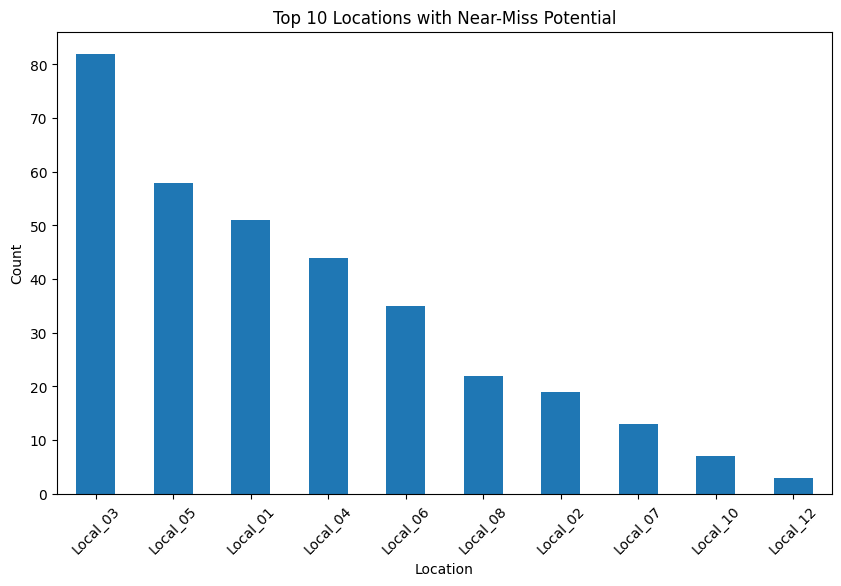

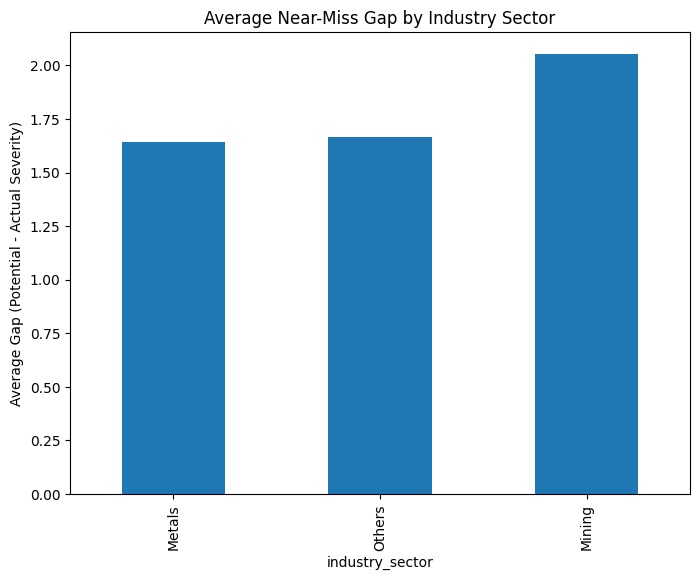

Critical risks with highest near-miss potential:
critical_risk
Electrical Shock                             3.000000
Projection of fragments                      3.000000
Projection                                   2.307692
Vehicles and Mobile Equipment                2.250000
Pressurized Systems / Chemical Substances    2.000000
Liquid Metal                                 2.000000
Confined space                               2.000000
Individual protection equipment              2.000000
Fall prevention                              2.000000
Projection/Manual Tools                      2.000000
Name: near_miss_gap, dtype: float64


In [15]:
# Where are near-misses happening?
near_misses = data_set[data_set['near_miss_gap'] > 0]

# Near-miss by location
plt.figure(figsize=(10, 6))
near_misses['local'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Locations with Near-Miss Potential')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Near-miss by industry sector
plt.figure(figsize=(8, 6))
near_misses.groupby('industry_sector')['near_miss_gap'].mean().sort_values().plot(kind='bar')
plt.title('Average Near-Miss Gap by Industry Sector')
plt.ylabel('Average Gap (Potential - Actual Severity)')
plt.show()

# Critical risks with highest near-miss potential
risk_nearmiss = data_set.groupby('critical_risk')['near_miss_gap'].mean().sort_values(ascending=False).head(10)
print("Critical risks with highest near-miss potential:")
print(risk_nearmiss)

**Monthly & Seasonal Trends**

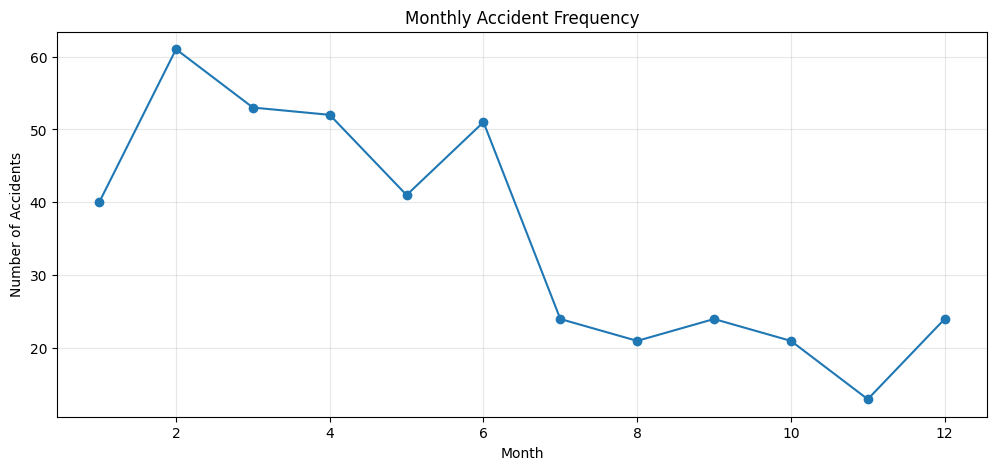

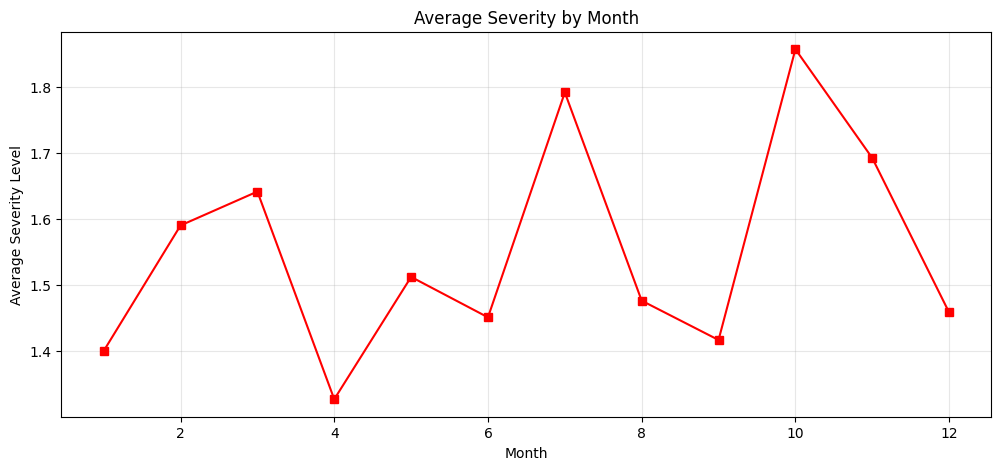

In [16]:
# Monthly accident trends
monthly_data = data_set.groupby('month').size()
plt.figure(figsize=(12, 5))
monthly_data.plot(marker='o')
plt.title('Monthly Accident Frequency')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.grid(True, alpha=0.3)
plt.show()

# Severity trends over time
monthly_severity = data_set.groupby('month')['severity'].mean()
plt.figure(figsize=(12, 5))
monthly_severity.plot(marker='s', color='red')
plt.title('Average Severity by Month')
plt.xlabel('Month')
plt.ylabel('Average Severity Level')
plt.grid(True, alpha=0.3)
plt.show()

**Employee vs Third Party Analysis**

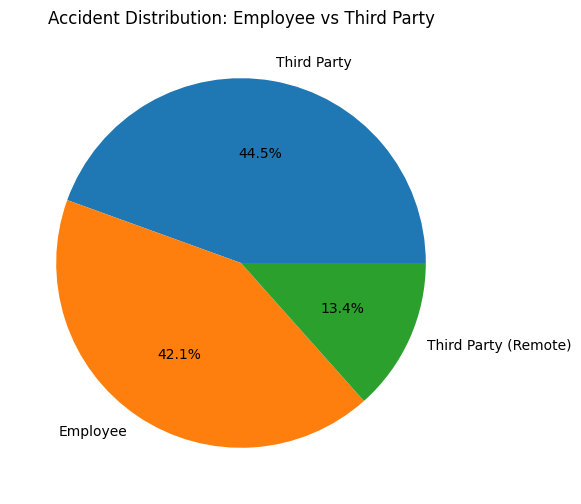

Severity by Employment Type:
                             mean  count
employee_or_third_party                 
Employee                 1.407821    179
Third Party              1.629630    189
Third Party (Remote)     1.561404     57

Top 5 risks for each employment type:
critical_risk            Bees  Chemical substances  Cut  Fall  Manual Tools  \
employee_or_third_party                                                       
Employee                  NaN                  9.0  8.0   NaN           7.0   
Third Party               9.0                  NaN  NaN   NaN           7.0   
Third Party (Remote)      NaN                  6.0  NaN   4.0           6.0   

critical_risk            Others  Pressed  Venomous Animals  
employee_or_third_party                                     
Employee                  100.0     12.0               NaN  
Third Party               109.0      7.0              12.0  
Third Party (Remote)       23.0      5.0               NaN  


In [17]:
# Accident distribution by employment type
plt.figure(figsize=(8, 6))
data_set['employee_or_third_party'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Accident Distribution: Employee vs Third Party')
plt.ylabel('')
plt.show()

# Severity by employment type
emp_severity = data_set.groupby('employee_or_third_party')['severity'].agg(['mean', 'count'])
print("Severity by Employment Type:")
print(emp_severity)

# Cross-tabulation
emp_risk_crosstab = pd.crosstab(data_set['employee_or_third_party'], data_set['critical_risk'])
print("\nTop 5 risks for each employment type:")
print(emp_risk_crosstab.apply(lambda x: x.nlargest(5), axis=1))

**Gender Analysis**

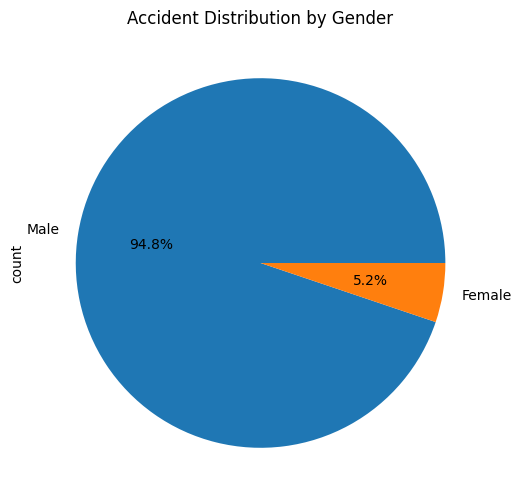

Severity Statistics by Gender:
        count      mean       std  min  25%  50%  75%  max
gender                                                    
Female   22.0  1.227273  0.528413  1.0  1.0  1.0  1.0  3.0
Male    403.0  1.543424  1.041418  1.0  1.0  1.0  2.0  5.0


In [18]:
# Gender distribution in accidents
plt.figure(figsize=(8, 6))
data_set['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Accident Distribution by Gender')
plt.show()

# Severity by gender
gender_severity = data_set.groupby('gender')['severity'].describe()
print("Severity Statistics by Gender:")
print(gender_severity)

In [19]:
from google.colab import files

file_name = "cleaned_safety_data_set_A.csv"
data_set.to_csv(file_name, index=False)
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# Example: stratified summary for all categorical columns
categorical_cols = ['countries', 'local', 'industry_sector', 'gender',
                    'employee_or_third_party', 'critical_risk']

for col in categorical_cols:
    print(f"\n=== Severity distribution by {col} ===")
    crosstab = pd.crosstab(data_set[col], data_set['severity'], margins=True)
    print(crosstab)
    # Optional: plot heatmap or bar chart
for col in categorical_cols:
    print(f"\nMean severity by {col}:")
    print(data_set.groupby(col)['severity'].mean().sort_values(ascending=False))


=== Severity distribution by countries ===
severity      1   2   3   4  5  All
countries                          
Country_01  180  19  21  23  8  251
Country_02   99  19   7   5  0  130
Country_03   37   2   3   2  0   44
All         316  40  31  30  8  425

=== Severity distribution by local ===
severity    1   2   3   4  5  All
local                            
Local_01   46   1   5   4  1   57
Local_02   15   6   2   1  0   24
Local_03   66   8   5   8  3   90
Local_04   31   9   7   6  3   56
Local_05   51   6   2   0  0   59
Local_06   36   1   3   5  1   46
Local_07    9   2   1   2  0   14
Local_08   19   5   1   2  0   27
Local_09    1   0   1   0  0    2
Local_10   37   2   3   2  0   44
Local_11    1   0   1   0  0    2
Local_12    4   0   0   0  0    4
All       316  40  31  30  8  425

=== Severity distribution by industry_sector ===
severity           1   2   3   4  5  All
industry_sector                         
Metals           107  12   7   7  1  134
Mining           

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Prepare a simple feature set (using only numeric features for demo)
X = data_set[['weekday', 'month']]  # placeholder – you can add more numeric features
y = data_set['severity']

# Encode categorical features if needed (skip for brevity)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Without class weights
clf_no_weight = LogisticRegression(max_iter=1000)
clf_no_weight.fit(X_train, y_train)
print("Without class weights:\n", classification_report(y_test, clf_no_weight.predict(X_test)))

# With class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(zip(np.unique(y_train), class_weights))
clf_weight = LogisticRegression(class_weight=weight_dict, max_iter=1000)
clf_weight.fit(X_train, y_train)
print("With class weights:\n", classification_report(y_test, clf_weight.predict(X_test)))

Without class weights:
               precision    recall  f1-score   support

           1       0.80      1.00      0.89        68
           2       0.00      0.00      0.00         6
           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         2

    accuracy                           0.80        85
   macro avg       0.16      0.20      0.18        85
weighted avg       0.64      0.80      0.71        85

With class weights:
               precision    recall  f1-score   support

           1       0.75      0.13      0.23        68
           2       0.00      0.00      0.00         6
           3       0.07      0.20      0.10         5
           4       0.09      0.25      0.13         4
           5       0.06      1.00      0.11         2

    accuracy                           0.15        85
   macro avg       0.19      0.32      0.11        85
weighted avg       0.61      0.1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
print("Resampled class distribution:", Counter(y_resampled))

Resampled class distribution: Counter({1: 248, 2: 248, 3: 248, 5: 248, 4: 248})
